In [1]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
load_dotenv()

True

In [3]:
model = init_chat_model("google_genai:gemini-2.5-flash-lite")

In [4]:
class ChatState(MessagesState):
    summary: str

In [5]:
def summarize_conversation(state: ChatState):

    existing_summary = state["summary"]

    # Build summarization prompt
    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [
        HumanMessage(content=prompt)
    ]

    response = model.invoke(messages_for_summary)

    # Keep only last 2 messages verbatim
    messages_to_delete = state["messages"][:-2]

    return {
        "summary": response.content,
        "messages": [RemoveMessage(id=m.id) for m in messages_to_delete],
    }

In [6]:
def chat_node(state: ChatState):
    messages = []

    if state["summary"]:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)
    return {"messages": [response]}

In [7]:
def should_summarize(state: ChatState):
    return len(state["messages"]) > 6

In [8]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [9]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

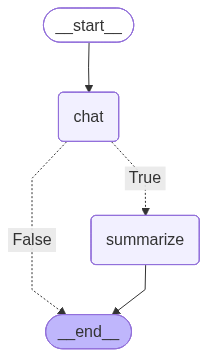

In [10]:
graph

In [11]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [12]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [13]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8c6c019f-794f-485e-aa44-8807e68933b3')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics is a fundamental theory in physics that describes nature at the 


In [14]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8c6c019f-794f-485e-aa44-8807e68933b3'), AIMessage(content='Quantum physics is a fundamental theory in physics that describes nature at the smallest scales of energy and matter – atoms and subatomic particles. It\'s a realm where our everyday intuition often breaks down, leading to some of the most mind-bending and fascinating concepts in science.\n\nHere\'s a breakdown of key aspects of quantum physics:\n\n**Core Concepts and Principles:**\n\n*   **Quantization:** This is the root of the word "quantum." It means that certain physical properties, like energy, momentum, and electric charge, are not continuous but exist in discrete packets or "quanta." Imagine a staircase versus a ramp – you can only be on specific steps, not anywhere in between.\n    *   **Example:** Electrons in an atom can only occupy specific energy levels. When they jump between these levels, they emit or absorb photons (quanta o

In [15]:
run_turn('What are some of Einstien"s famous work')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8c6c019f-794f-485e-aa44-8807e68933b3'), AIMessage(content='Quantum physics is a fundamental theory in physics that describes nature at the smallest scales of energy and matter – atoms and subatomic particles. It\'s a realm where our everyday intuition often breaks down, leading to some of the most mind-bending and fascinating concepts in science.\n\nHere\'s a breakdown of key aspects of quantum physics:\n\n**Core Concepts and Principles:**\n\n*   **Quantization:** This is the root of the word "quantum." It means that certain physical properties, like energy, momentum, and electric charge, are not continuous but exist in discrete packets or "quanta." Imagine a staircase versus a ramp – you can only be on specific steps, not anywhere in between.\n    *   **Example:** Electrons in an atom can only occupy specific energy levels. When they jump between these levels, they emit or absorb photons (quanta o

In [16]:
run_turn('Explain special theory of relativity')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='8c6c019f-794f-485e-aa44-8807e68933b3'), AIMessage(content='Quantum physics is a fundamental theory in physics that describes nature at the smallest scales of energy and matter – atoms and subatomic particles. It\'s a realm where our everyday intuition often breaks down, leading to some of the most mind-bending and fascinating concepts in science.\n\nHere\'s a breakdown of key aspects of quantum physics:\n\n**Core Concepts and Principles:**\n\n*   **Quantization:** This is the root of the word "quantum." It means that certain physical properties, like energy, momentum, and electric charge, are not continuous but exist in discrete packets or "quanta." Imagine a staircase versus a ramp – you can only be on specific steps, not anywhere in between.\n    *   **Example:** Electrons in an atom can only occupy specific energy levels. When they jump between these levels, they emit or absorb photons (quanta o